In [1]:
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import ResNet50, MobileNetV2, EfficientNetB0
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import Precision, Recall
import matplotlib.pyplot as plt
import numpy as np

In [2]:
from tensorflow.keras.applications.efficientnet import preprocess_input

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input, ##changed 
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2] ##Added , removed shear range
)

val_test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

In [3]:
train_generator = train_datagen.flow_from_directory(
    "split_dataset/train",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_generator = val_test_datagen.flow_from_directory(
    "split_dataset/val",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

test_generator = val_test_datagen.flow_from_directory(
    "split_dataset/test",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

num_classes = train_generator.num_classes

Found 3323 images belonging to 9 classes.
Found 712 images belonging to 9 classes.
Found 717 images belonging to 9 classes.


In [4]:
class ChannelAvgPool(layers.Layer):
    def call(self, inputs):
        return tf.reduce_mean(inputs, axis=3, keepdims=True)

class ChannelMaxPool(layers.Layer):
    def call(self, inputs):
        return tf.reduce_max(inputs, axis=3, keepdims=True)

def channel_attention(input_feature, ratio=8):
    channel = input_feature.shape[-1]

    avg_pool = layers.GlobalAveragePooling2D()(input_feature)
    avg_pool = layers.Reshape((1, 1, channel))(avg_pool)

    max_pool = layers.GlobalMaxPooling2D()(input_feature)
    max_pool = layers.Reshape((1, 1, channel))(max_pool)

    shared_dense_1 = layers.Dense(channel // ratio, activation='relu')
    shared_dense_2 = layers.Dense(channel)

    avg_out = shared_dense_2(shared_dense_1(avg_pool))
    max_out = shared_dense_2(shared_dense_1(max_pool))

    cbam_feature = layers.Add()([avg_out, max_out])
    cbam_feature = layers.Activation('sigmoid')(cbam_feature)

    return layers.Multiply()([input_feature, cbam_feature])

def spatial_attention(input_feature):
    avg_pool = ChannelAvgPool()(input_feature)
    max_pool = ChannelMaxPool()(input_feature)

    concat = layers.Concatenate(axis=3)([avg_pool, max_pool])

    cbam_feature = layers.Conv2D(1, 7, padding='same', activation='sigmoid')(concat)

    return layers.Multiply()([input_feature, cbam_feature])

def cbam_block(input_feature):
    x = channel_attention(input_feature)
    x = spatial_attention(x)
    return x

In [5]:
input_tensor = layers.Input(shape=(224, 224, 3))

resnet = ResNet50(weights='imagenet', include_top=False, input_tensor=input_tensor)
mobilenet = MobileNetV2(weights='imagenet', include_top=False, input_tensor=input_tensor)
efficientnet = EfficientNetB0(weights='imagenet', include_top=False, input_tensor=input_tensor)

# Freeze ALL layers initially
for model in [resnet, mobilenet, efficientnet]:
    for layer in model.layers:
        layer.trainable = False

C:\Users\Admin\AppData\Local\Temp\ipykernel_8332\1140951181.py:4: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  mobilenet = MobileNetV2(weights='imagenet', include_top=False, input_tensor=input_tensor)


In [6]:
resnet_cbam = cbam_block(resnet.output)
mobilenet_cbam = cbam_block(mobilenet.output)
efficientnet_cbam = cbam_block(efficientnet.output)

resnet_gap = layers.GlobalAveragePooling2D()(resnet_cbam)
mobilenet_gap = layers.GlobalAveragePooling2D()(mobilenet_cbam)
efficientnet_gap = layers.GlobalAveragePooling2D()(efficientnet_cbam)

fused = layers.Concatenate()([resnet_gap, mobilenet_gap, efficientnet_gap])

In [7]:
x = layers.Dense(512)(fused)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)
x = layers.Dropout(0.5)(x)

x = layers.Dense(256, activation='relu')(x)

output = layers.Dense(num_classes, activation='softmax')(x)

model = Model(inputs=input_tensor, outputs=output)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 34,264,021 (130.71 MB)

 Trainable params: 4,367,730 (16.66 MB)

 Non-trainable params: 29,896,291 (114.05 MB)

In [8]:
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy', Precision(), Recall()]
)

In [9]:
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=3, min_lr=1e-6)

checkpoint = ModelCheckpoint("best_model.keras", monitor='val_accuracy', save_best_only=True)

In [10]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    callbacks=[early_stop, reduce_lr, checkpoint]
)

Epoch 1/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 599s 5s/step - accuracy: 0.4589 - loss: 1.7174 - precision: 0.6780 - recall: 0.2510 - val_accuracy: 0.6629 - val_loss: 1.3388 - val_precision: 0.8955 - val_recall: 0.2528 - learning_rate: 1.0000e-04
Epoch 2/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 522s 5s/step - accuracy: 0.6988 - loss: 1.1826 - precision: 0.8426 - recall: 0.5284 - val_accuracy: 0.7626 - val_loss: 1.0706 - val_precision: 0.8899 - val_recall: 0.5449 - learning_rate: 1.0000e-04
Epoch 3/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 477s 5s/step - accuracy: 0.7665 - loss: 1.0503 - precision: 0.8709 - recall: 0.6250 - val_accuracy: 0.7935 - val_loss: 0.9821 - val_precision: 0.8796 - val_recall: 0.6770 - learning_rate: 1.0000e-04
Epoch 4/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 459s 4s/step - accuracy: 0.8122 - loss: 0.9599 - precision: 0.8975 - recall: 0.6927 - val_accuracy: 0.8006 - val_loss: 0.9668 - val_precision: 0.8711 - val_recall: 0.7121 - learning_rate: 1.0000e-04
Epoch 5/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 463s

In [11]:
# Unfreeze LAST layers only
for base_model in [resnet, mobilenet, efficientnet]:
    for layer in base_model.layers[-30:]:
        layer.trainable = True

# Recompile with LOW LR
model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy', Precision(), Recall()]
)

In [12]:
history_finetune = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 616s 5s/step - accuracy: 0.8450 - loss: 0.9177 - precision_1: 0.9353 - recall_1: 0.6912 - val_accuracy: 0.8596 - val_loss: 0.8933 - val_precision_1: 0.9067 - val_recall_1: 0.8188 - learning_rate: 1.0000e-05
Epoch 2/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 609s 6s/step - accuracy: 0.8844 - loss: 0.8242 - precision_1: 0.9517 - recall_1: 0.7773 - val_accuracy: 0.8469 - val_loss: 0.9284 - val_precision_1: 0.8833 - val_recall_1: 0.8076 - learning_rate: 1.0000e-05
Epoch 3/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 639s 6s/step - accuracy: 0.9203 - loss: 0.7518 - precision_1: 0.9630 - recall_1: 0.8369 - val_accuracy: 0.8455 - val_loss: 0.9320 - val_precision_1: 0.8814 - val_recall_1: 0.8034 - learning_rate: 1.0000e-05
Epoch 4/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 597s 6s/step - accuracy: 0.9260 - loss: 0.7426 - precision_1: 0.9666 - recall_1: 0.8525 - val_accuracy: 0.8455 - val_loss: 0.9290 - val_precision_1: 0.8854 - val_recall_1: 0.8034 - learning_rate: 3.0000e-06
Epoch 5/10
1

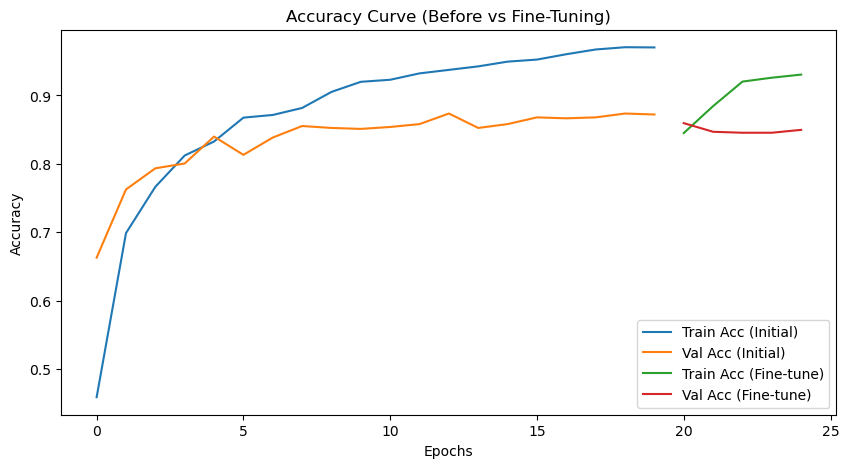

In [13]:
plt.figure(figsize=(10,5))

# Initial training
plt.plot(history.history['accuracy'], label='Train Acc (Initial)')
plt.plot(history.history['val_accuracy'], label='Val Acc (Initial)')

# Fine-tuning (continue curve)
plt.plot(range(len(history.history['accuracy']), 
               len(history.history['accuracy']) + len(history_finetune.history['accuracy'])),
         history_finetune.history['accuracy'], label='Train Acc (Fine-tune)')

plt.plot(range(len(history.history['val_accuracy']), 
               len(history.history['val_accuracy']) + len(history_finetune.history['val_accuracy'])),
         history_finetune.history['val_accuracy'], label='Val Acc (Fine-tune)')

plt.title("Accuracy Curve (Before vs Fine-Tuning)")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

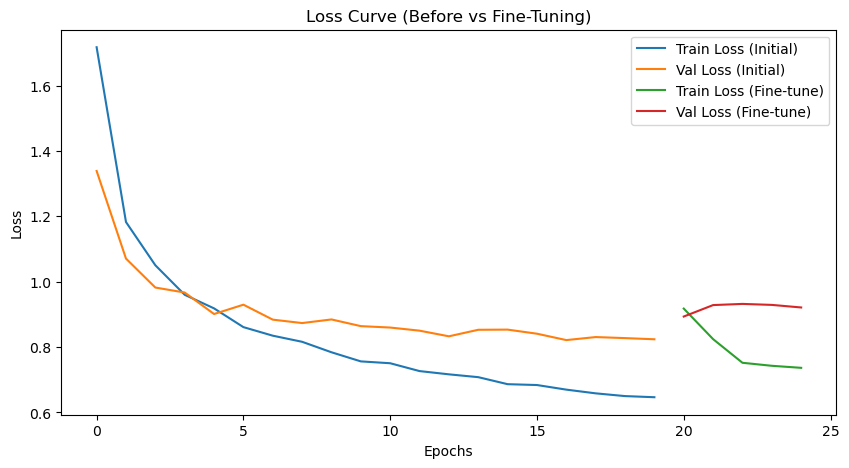

In [14]:
plt.figure(figsize=(10,5))

plt.plot(history.history['loss'], label='Train Loss (Initial)')
plt.plot(history.history['val_loss'], label='Val Loss (Initial)')

plt.plot(range(len(history.history['loss']), 
               len(history.history['loss']) + len(history_finetune.history['loss'])),
         history_finetune.history['loss'], label='Train Loss (Fine-tune)')

plt.plot(range(len(history.history['val_loss']), 
               len(history.history['val_loss']) + len(history_finetune.history['val_loss'])),
         history_finetune.history['val_loss'], label='Val Loss (Fine-tune)')

plt.title("Loss Curve (Before vs Fine-Tuning)")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [15]:
model.load_weights("best_model.keras")

test_loss, test_acc, test_precision, test_recall = model.evaluate(test_generator)

print("Test Accuracy:", test_acc)
print("Test Precision:", test_precision)
print("Test Recall:", test_recall)

C:\Users\Admin\anaconda3\Lib\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 246 variables whereas the saved optimizer has 54 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


23/23 ━━━━━━━━━━━━━━━━━━━━ 71s 3s/step - accuracy: 0.8675 - loss: 0.8299 - precision_1: 0.9221 - recall_1: 0.8089
Test Accuracy: 0.8675034642219543
Test Precision: 0.9220985770225525
Test Recall: 0.8089261054992676


23/23 ━━━━━━━━━━━━━━━━━━━━ 87s 3s/step
📊 Classification Report:

                     precision    recall  f1-score   support

          Cardboard       0.85      0.96      0.90        70
      Food Organics       0.92      0.92      0.92        62
              Glass       0.90      0.86      0.88        63
              Metal       0.79      0.92      0.85       119
Miscellaneous Trash       0.78      0.75      0.76        75
              Paper       0.97      0.83      0.89        75
            Plastic       0.93      0.80      0.86       139
      Textile Trash       0.89      0.85      0.87        48
         Vegetation       0.86      0.97      0.91        66

           accuracy                           0.87       717
          macro avg       0.88      0.87      0.87       717
       weighted avg       0.87      0.87      0.87       717



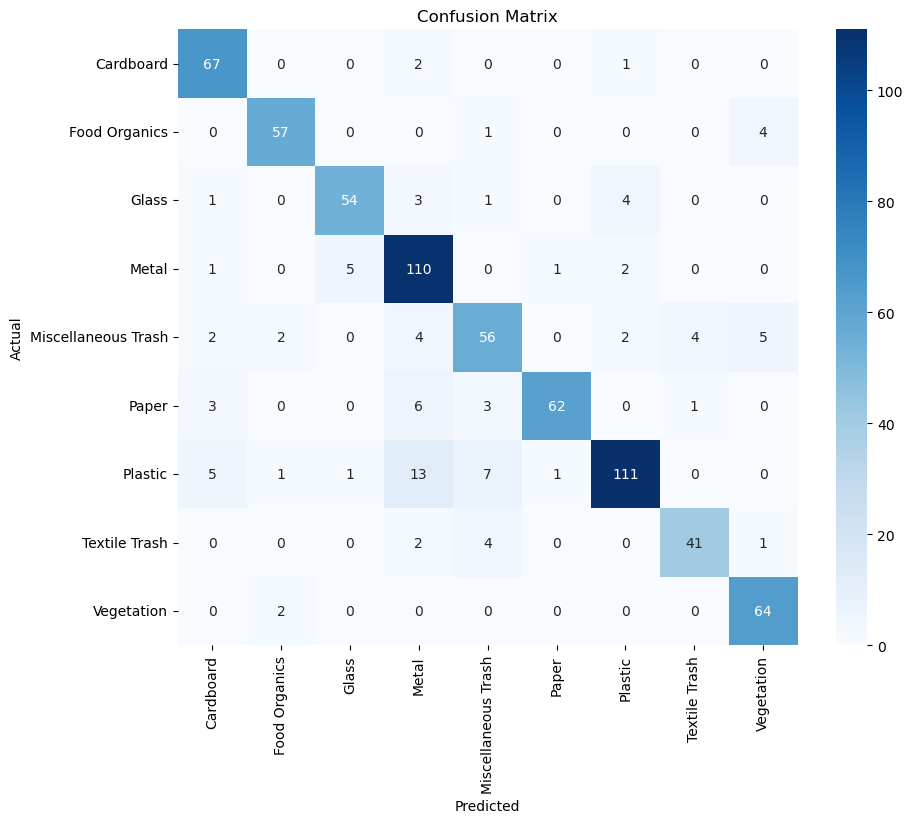

In [16]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Predictions
y_pred_probs = model.predict(test_generator)
y_pred = np.argmax(y_pred_probs, axis=1)

y_true = test_generator.classes
class_labels = list(test_generator.class_indices.keys())

# Report
print("📊 Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_labels))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels,
            yticklabels=class_labels)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

Total Misclassified: 95


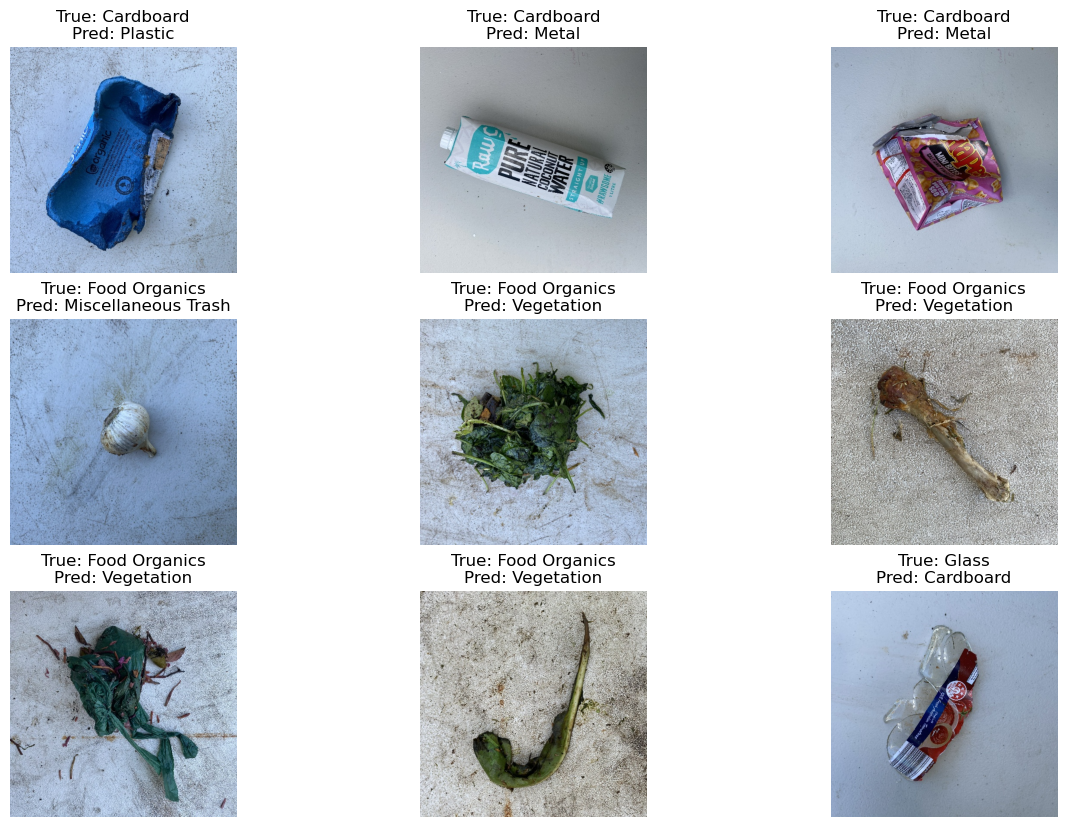

In [17]:
import matplotlib.pyplot as plt
import cv2

file_paths = test_generator.filepaths
misclassified = np.where(y_pred != y_true)[0]

print("Total Misclassified:", len(misclassified))

plt.figure(figsize=(15,10))

for i, idx in enumerate(misclassified[:9]):
    img = cv2.imread(file_paths[idx])
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    true_label = class_labels[y_true[idx]]
    pred_label = class_labels[y_pred[idx]]

    plt.subplot(3,3,i+1)
    plt.imshow(img)
    plt.title(f"True: {true_label}\nPred: {pred_label}")
    plt.axis('off')

plt.show()

In [74]:
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

# For file upload
from IPython.display import display
import ipywidgets as widgets

# Create upload button
upload = widgets.FileUpload(accept='image/*', multiple=False)
display(upload)

FileUpload(value=(), accept='image/*', description='Upload')

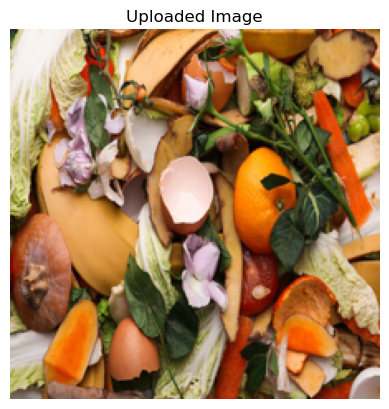

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step
Predicted Class: Food Organics
Confidence: 0.79759294


In [76]:
from tensorflow.keras.applications.efficientnet import preprocess_input
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import io

# Check if file uploaded
if upload.value:
    
    # Handle both tuple and dict cases
    uploaded_file = upload.value[0] if isinstance(upload.value, tuple) else list(upload.value.values())[0]
    
    img_bytes = uploaded_file['content']
    
    # Load image
    img = Image.open(io.BytesIO(img_bytes)).convert('RGB')
    img = img.resize((224, 224))
    
    # Show image
    plt.imshow(img)
    plt.title("Uploaded Image")
    plt.axis('off')
    plt.show()
    
    # Preprocess
    img_array = np.array(img)
    img_array = preprocess_input(img_array)
    img_array = np.expand_dims(img_array, axis=0)
    
    # Predict
    pred = model.predict(img_array)[0]
    
    class_labels = list(train_generator.class_indices.keys())
    pred_class = np.argmax(pred)
    
    print("Predicted Class:", class_labels[pred_class])
    print("Confidence:", np.max(pred))

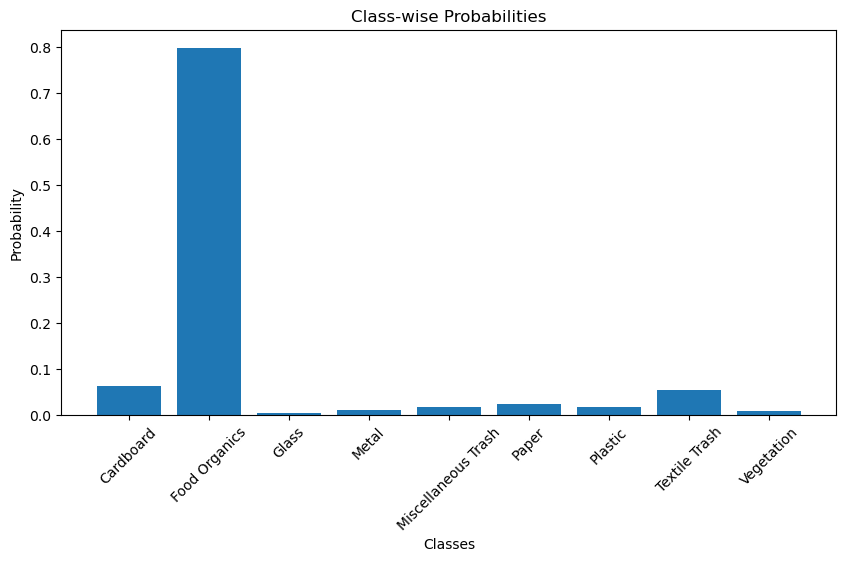

In [77]:
plt.figure(figsize=(10,5))

plt.bar(class_labels, pred)
plt.xticks(rotation=45)

plt.title("Class-wise Probabilities")
plt.xlabel("Classes")
plt.ylabel("Probability")

plt.show()

In [78]:
sorted_idx = np.argsort(pred)[::-1]

print("Top Predictions:\n")

for idx in sorted_idx:
    print(f"{class_labels[idx]}: {pred[idx]:.4f}")

Top Predictions:

Food Organics: 0.7976
Cardboard: 0.0638
Textile Trash: 0.0542
Paper: 0.0246
Miscellaneous Trash: 0.0174
Plastic: 0.0171
Metal: 0.0112
Vegetation: 0.0092
Glass: 0.0050


In [79]:
print("Predicted Class:", class_labels[pred_class])
print("Confidence:", np.max(pred))

Predicted Class: Food Organics
Confidence: 0.79759294


In [80]:
# End-of-Life (EOL) Recommendations

eol_recommendations = {

    "Cardboard": {
        "disposal": "Recycle through paper and cardboard recycling facilities",
        "impact": "Recycling cardboard reduces deforestation and landfill waste"
    },

    "Food Organics": {
        "disposal": "Use composting or organic waste treatment methods",
        "impact": "Organic waste can be converted into compost or biogas"
    },

    "Glass": {
        "disposal": "Send to glass recycling centers for reuse and processing",
        "impact": "Glass is fully recyclable and reduces raw material consumption"
    },

    "Metal": {
        "disposal": "Recycle through authorized scrap metal recycling facilities",
        "impact": "Metal recycling conserves natural resources and energy"
    },

    "Miscellaneous Trash": {
        "disposal": "Dispose through municipal landfill or waste-to-energy treatment",
        "impact": "Improper disposal may increase environmental pollution"
    },

    "Paper": {
        "disposal": "Recycle with dry paper waste for paper recovery",
        "impact": "Paper recycling reduces tree cutting and saves energy"
    },

    "Plastic": {
        "disposal": "Send to plastic recycling facilities for proper processing",
        "impact": "Plastic recycling helps reduce soil and ocean pollution"
    },

    "Textile Trash": {
        "disposal": "Reuse, donate, or recycle through textile recovery systems",
        "impact": "Textile recycling minimizes fabric waste accumulation"
    },

    "Vegetation": {
        "disposal": "Use composting or biodegradable waste processing methods",
        "impact": "Vegetation waste can enrich soil through compost generation"
    }
}

In [81]:
print("Predicted Class:", class_labels[pred_class])
print("Confidence:", np.max(pred))

Predicted Class: Food Organics
Confidence: 0.79759294


In [82]:
# Predicted label
predicted_label = class_labels[pred_class]

# Fetch EOL recommendation
eol = eol_recommendations[predicted_label]

print("\n End-of-Life Recommendation")
print("Disposal Method :", eol["disposal"])
print("Environmental Impact :", eol["impact"])


 End-of-Life Recommendation
Disposal Method : Use composting or organic waste treatment methods
Environmental Impact : Organic waste can be converted into compost or biogas


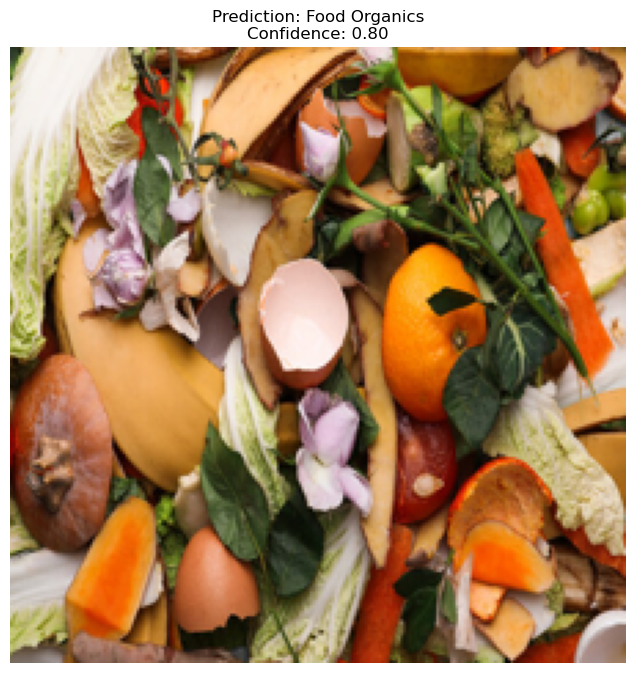

In [83]:
plt.figure(figsize=(8,8))

plt.imshow(img)

plt.title(
    f"Prediction: {predicted_label}\n"
    f"Confidence: {np.max(pred):.2f}"
)

plt.axis('off')

plt.show()

In [85]:
# Save complete model
model.save("final_eol_model.keras")

# Save weights correctly
model.save_weights("final_eol_model.weights.h5")

print("✅ Model and weights saved successfully!")

✅ Model and weights saved successfully!
